Based on the [BK2016](https://arxiv.org/abs/1607.01360) self-similar scaling $E(k\xi(t),t) = \xi^{-\beta}\,\phi(k\xi)$ with $\xi \propto t^q$.
Total energy decays as $\mathcal{E}(t)\propto(1+t/t_1)^{-p}$.  

## Piecewise spectrum
$$
\phi(k\xi)=
\begin{cases}
C\, k^{s}, & k < k_0(t) \\
C'\, k^{-5/3}, & k > k_0(t)
\end{cases}
$$

s will be take to be equal to 4

| $\beta$ | $q$ | $p$ | $k_0(t)$ |
|---------|-----|-----|----------|
| 4 | 2/7 | 10/7 | $k_0(t_0)\left(1+t/t_1\right)^{-2/7}$ |
| 1 | 1/2 | 1   | $k_0(t_0)\left(1+t/t_1\right)^{-1/2}$ |
| 0 | 2/3 | 2/3 | $k_0(t_0)\left(1+t/t_1\right)^{-2/3}$ |


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatLogSlider, FloatSlider, Dropdown, fixed
from IPython.display import display
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

%matplotlib widget

plt.rcParams.update({'figure.dpi': 100, 'font.size': 20})

In [7]:
def phi_spec(kappa, s = 4, kappa_peak = 1.0):
    """
    self simular shape defined picwise 
    k^s below and  k^{-5/3} above peak
    """
    kappa = np.asarray(kappa,dtype=float)
    C_prime = kappa_peak ** (s + 5/3)
    out = np.where(kappa <kappa_peak, kappa ** s, C_prime * kappa ** (-5/3))
    return out

def xi_t(t, q, t1 =1):
    """
    normalized time dependat length scale 
    xi(t)/xi(0) = (1 + t/t1) ^q
    """
    return (1 + t/t1) ** q

def E_spec(k, t, beta ,q_exp, k0_init=1, t1=1, s=4):
    """
    following anazatz form papae BK2016
    E(k,t) = xi ^{-beta}  phi(k/k_0 * xi(t)/xi(0))
    """
    xi = xi_t(t,q_exp,t1)
    kappa = k * xi / k0_init
    return  xi ** (-beta) * phi_spec(kappa, s=s, kappa_peak=1.0)

def k_peak_t(t, k0_init,q_exp, t1=1):
    """
    k(t) = k0*xi(0)  / xi(t)
    """
    return k0_init / xi_t(t, q_exp, t1)

def E_at_peak(t,k0_init,beta,q_exp, t1=1,s=4):
    """
    E(kpeak,t)
    """
    kp = k_peak_t(t,k0_init,q_exp,t1)
    return E_spec(kp, t, beta, q_exp, k0_init,t1,s)


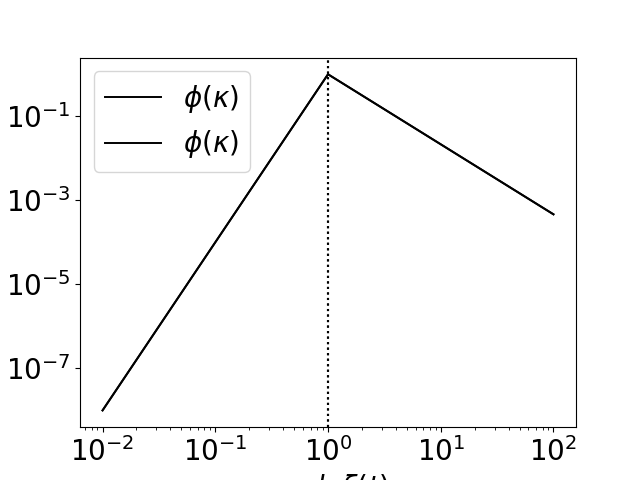

In [8]:
kappa_test = np.logspace(-2,2,1000)
phi_test = phi_spec(kappa_test,s=4, kappa_peak=1.0)



plt.loglog(kappa_test,phi_test,lw =1.4,c="black", label=r"$\phi(\kappa)$")
plt.axvline(1.0,ymin=0, ymax=1, ls=":", c="black")

plt.xlabel(r"$\kappa = k ~ \xi(t)$")
plt.legend()
plt.show()